In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import blimpy as bl 
import setigen as stg 
import glob
import os 
from astropy import units as u
%matplotlib inline

plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"

In [2]:
file = '/datax/scratch/gillislowry/converted_atlas/AI-ATLAS_D20260210T235610_chan143-143_lane0_beam0.h5'

In [3]:
fb = bl.Waterfall(file, load_data=False)

In [4]:
fb.info()


--- File Info ---
DIMENSION_LABELS : [b'time' b'feed_id' b'frequency']
        az_start :                              0.0
        chan_idx :                              143
       data_type :                                1
            fch1 :            27.83203274011612 MHz
            foff :       2.9802322387695312e-06 MHz
           ibeam :                                0
      machine_id :                                0
          nbeams :                                0
           nbits :                                8
          nchans :                         12582912
            nfpc :                          1048576
            nifs :                                1
    nof_beamlets :                              192
     rawdatafile :                          unknown
     source_name :                          unknown
         src_dej :                          0:00:00
         src_raj :                          0:00:00
    telescope_id :                          

In [5]:
22*2.68435456

59.05580032

In [2]:
2.98023/2.68435456

1.110222190618515

In [66]:
frame = stg.Frame(waterfall=fb)

In [67]:
ff = [42.679845, 45.324698, 51.034981, 54.109583, 58.230944]
dd = [-3.245069, 1.467800, -0.457982, -0.309185, 0.896312]

for i in range(len(ff)):

    f = ff[i]
    d = dd[i]
    w = 1
    s = 1500

    dsign = np.sign(d)

    # Define a bounding box for this signal.
    # The mins and maxes are to account for fch1 sometimes being the leftmost and sometimes the rightmost frequency.

    lb = np.min(((f-dsign*0.0001), (f+d*(1e-6)*300+dsign*0.0001)))
    rb = np.max(((f-dsign*0.0001), (f+d*(1e-6)*300+dsign*0.0001)))

    data_window = bl.Waterfall(file, lb, rb)
    subc = stg.Frame(data_window)

    frame.add_signal(path = stg.constant_path(f_start=(f*u.MHz),
                               drift_rate=d*u.Hz/u.s),
                           t_profile = stg.constant_t_profile(level=subc.get_intensity(snr=s)),
                           f_profile = stg.box_f_profile(width=w*frame.df*u.Hz),
                           #bp_profile = pfb_corr[np.argmin(np.abs(freqs-rb)):np.argmin(np.abs(freqs-lb))],
                           #stg.constant_bp_profile(level=1),
                           #integrate_t_profile=True,
                           #integrate_f_profile=True,
                           #integrate_path=True,
                           doppler_smearing=True,
                           smearing_subsamples=15,
                           bounding_f_range=(lb*u.MHz, rb*u.MHz))

In [68]:
fb_new = bl.Waterfall(filename=None, header_dict=fb.header, data_array=np.expand_dims(frame.data, axis=1).astype('<f4'))

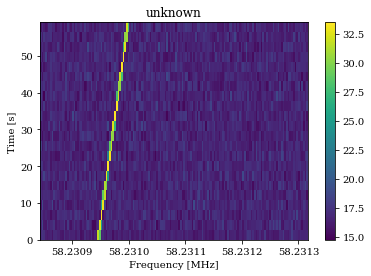

In [69]:
fb_new.plot_waterfall(f_start=lb, f_stop=rb)

In [70]:
fb_new.write_to_hdf5('/datax/scratch/benjb/nenufar_blind_test.h5')

blimpy.waterfall INFO     __write_to_hdf5_light: Writing the spectra matrix for /datax/scratch/benjb/nenufar_blind_test.h5 without blobbing.
blimpy.waterfall INFO     Conversion time: 1.40sec


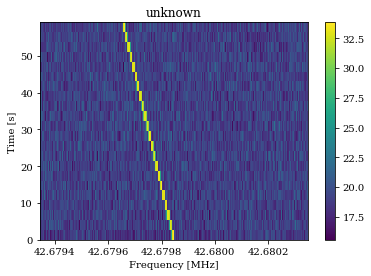

In [71]:
fbn = bl.Waterfall('/datax/scratch/benjb/nenufar_blind_test.h5')
i = 0
fbn.plot_waterfall(f_start=ff[i]-0.0005, f_stop=ff[i]+0.0005)

extracting integration 0...


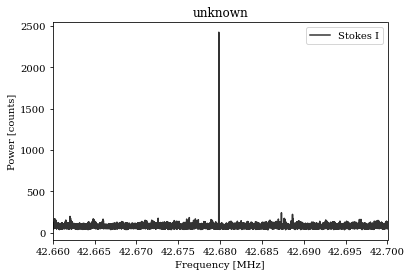

In [72]:
fbn.plot_spectrum(f_start=42.66, f_stop=42.7)

In [73]:
freq = fbn.get_freqs()

In [74]:
freq, dat = fbn.grab_data()

In [77]:
print(dat.shape)

(22, 12582912)


In [78]:
12582912/12

1048576.0

In [75]:
print(dat)

[[101.  99.  95. ...  36.  37.  37.]
 [ 61.  67.  84. ...  33.  39.  39.]
 [ 63.  70.  73. ...  36.  44.  47.]
 ...
 [ 55.  96.  74. ...  34.  37.  42.]
 [ 83.  66.  89. ...  35.  48.  36.]
 [ 99.  43.  60. ...  41.  47.  32.]]


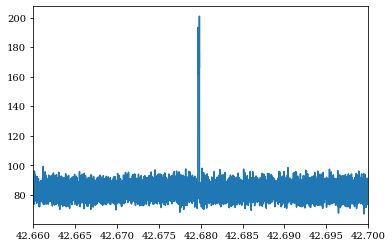

In [76]:
lb = 42.66
rb = 42.7
plt.plot(freq[(freq>lb)&(freq<rb)], np.average(np.squeeze(dat), axis=0)[(freq>lb)&(freq<rb)])
from scipy.signal import savgol_filter
#smoothed_y = savgol_filter(np.average(np.squeeze(fbn.data), axis=0)[(freq>lb)&(freq<rb)], window_length=31, polyorder=2)
#plt.plot(freq[(freq>lb)&(freq<rb)], smoothed_y)
plt.xlim(lb, rb)
plt.show()

In [49]:
print(np.min(freq))
print(np.max(freq))
print(np.max(freq)-np.min(freq))
37.5/12

27.83203274011612
65.33202975988388
37.49999701976776


3.125